In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/loan-dataset/LoanDataset - LoansDatasest.csv


In [2]:

!pip install skimpy
!pip install summarytools
!pip install polars

  Attempting uninstall: typing-extensions
    Found existing installation: typing_extensions 4.9.0
    Uninstalling typing_extensions-4.9.0:
      Successfully uninstalled typing_extensions-4.9.0
  Attempting uninstall: typeguard
    Found existing installation: typeguard 4.1.5
    Uninstalling typeguard-4.1.5:
      Successfully uninstalled typeguard-4.1.5
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-decision-forests 1.8.1 requires wurlitzer, which is not installed.
apache-beam 2.46.0 requires dill<0.3.2,>=0.3.1.1, but you have dill 0.3.8 which is incompatible.
apache-beam 2.46.0 requires numpy<1.25.0,>=1.14.3, but you have numpy 1.26.4 which is incompatible.
apache-beam 2.46.0 requires pyarrow<10.0.0,>=3.0.0, but you have pyarrow 16.1.0 which is incompatible.
jupyterlab 4.2.1 requires jupyter-lsp>=2.0.0, but you have jupyter-lsp 1.5.1 which is i

# Importing libraries

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
import polars as pl
from summarytools import dfSummary
from skimpy import skim

# Importing the Dataset

In [31]:
data=pd.read_csv("/kaggle/input/loan-dataset/LoanDataset - LoansDatasest.csv")

In [32]:
data.head()

,customer_id,customer_age,customer_income,home_ownership,employment_duration,loan_intent,loan_grade,loan_amnt,loan_int_rate,term_years,historical_default,cred_hist_length,Current_loan_status
0,1.0,22,59000,RENT,123.0,PERSONAL,C,"£35,000.00",16.02,10,Y,3,DEFAULT
1,2.0,21,9600,OWN,5.0,EDUCATION,A,"£1,000.00",11.14,1,NaN,2,NO DEFAULT
2,3.0,25,9600,MORTGAGE,1.0,MEDICAL,B,"£5,500.00",12.87,5,N,3,DEFAULT
3,4.0,23,65500,RENT,4.0,MEDICAL,B,"£35,000.00",15.23,10,N,2,DEFAULT
4,5.0,24,54400,RENT,8.0,MEDICAL,B,"£35,000.00",14.27,10,Y,4,DEFAULT


# Domain Analysis
1. customer_id: Unique identifier for each customer
2. customer_age: Age of the customer
3. customer_income: Annual income of the customer
4. home_ownership: Home ownership status (e.g., RENT, OWN, MORTGAGE)
5. employment_duration: Duration of employment in months
6. loan_intent: Purpose of the loan (e.g., PERSONAL, EDUCATION, MEDICAL, VENTURE)
7. loan_grade: Grade assigned to the loan
8. loan_amnt: Loan amount requested
9. loan_int_rate: Interest rate of the loan
10. term_years: Loan term in years
11. historical_default: Indicates if the customer has a history of default (Y/N)
12. cred_hist_length: Length of the customer's credit history in years
13. Current_loan_status: Current status of the loan (DEFAULT, NO DEFAULT)

# Basic checks

In [7]:
data.columns

Index(['customer_id', 'customer_age', 'customer_income', 'home_ownership',
       'employment_duration', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'term_years', 'historical_default', 'cred_hist_length',
       'Current_loan_status'],
      dtype='object')

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32586 entries, 0 to 32585
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer_id          32583 non-null  float64
 1   customer_age         32586 non-null  int64  
 2   customer_income      32586 non-null  object 
 3   home_ownership       32586 non-null  object 
 4   employment_duration  31691 non-null  float64
 5   loan_intent          32586 non-null  object 
 6   loan_grade           32586 non-null  object 
 7   loan_amnt            32585 non-null  object 
 8   loan_int_rate        29470 non-null  float64
 9   term_years           32586 non-null  int64  
 10  historical_default   11849 non-null  object 
 11  cred_hist_length     32586 non-null  int64  
 12  Current_loan_status  32582 non-null  object 
dtypes: float64(3), int64(3), object(7)
memory usage: 3.2+ MB


In [9]:
dfSummary(data)

No,Variable,Stats / Values,Freqs / (% of Valid),Graph,Missing
1,customer_id[float64],Mean (sd) : 16289.5 (9405.9)min < med < max:1.0 < 16288.0 < 32581.0IQR (CV) : 16289.0 (1.7),"32,577 distinct values","<img src = ""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAAKoAAABGCAYAAABc8A97AAAAOXRFWHRTb2Z0d2FyZQBNYXRwbG90bGliIHZlcnNpb24zLjcuNSwgaHR0cHM6Ly9tYXRwbG90bGliLm9yZy/xnp5ZAAAACXBIWXMAAA9hAAAPYQGoP6dpAAABxklEQVR4nO3XQU7CYBBA4fkbJSCkDSHCAbwBSw7hYT0EJ2DhxhU7EtKUUDEarCcAKTXqS963baczixcSUtM0If132V8fIF3i5rsXUkqDiOhd+f0sIj6vnO06T91Nvbvr/HvTNIdTD8+GmlIaTCaTxzzPx223Ho/H27quH0aj0UuWZR+/OU/dTb37J+Z3u12ZUno6Fet3v6i9PM/Hi8XiUBTFW5vF6/V6vFqt7ufz+fNsNivbzHadp+6m3t11vqqq/nK5HG+3215EXBVqREQURfE2nU5f2ywvy3IQETEcDlvPdp2n7qbe/RPzETE499A/U0IwVCEYqhAMVQiGKgRDFYKhCsFQhWCoQjBUIRiqEAxVCIYqBEMVgqEKwVCFYKhCMFQhGKoQDFUIhioEQxWCoQrBUIVgqEIwVCEYqhAMVQiGKgRDFYKhCsFQhWCoQjBUIRiqEAxVCIYqBEMVgqEKwVCFYKhCMFQhGKoQDFUIhioEQxWCoQrBUIVgqEIwVCEYqhAMVQiGKgRDFYKhCsFQhWCoQjBUIRiqEAxVCIYqBEMVgqEK4eaSl6qq6rf98H6/70dE1HXd32w2d785T91Nvbvr/CV9fQGSljnmc7n3zQAAAABJRU5ErkJggg=="">",3(0.0%)
2,customer_age[int64],Mean (sd) : 27.7 (6.4)min < med < max:3.0 < 26.0 < 144.0IQR (CV) : 7.0 (4.4),62 distinct values,"<img src = ""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAAKoAAABGCAYAAABc8A97AAAAOXRFWHRTb2Z0d2FyZQBNYXRwbG90bGliIHZlcnNpb24zLjcuNSwgaHR0cHM6Ly9tYXRwbG90bGliLm9yZy/xnp5ZAAAACXBIWXMAAA9hAAAPYQGoP6dpAAAB/0lEQVR4nO3azaraUBSG4bWqx26PNEGEOPMSOnDoRfRiz7TzXIsIQRPMMY3o7qjD/iQq5jt9n/naLMJLJLg9xmjA0H169gLAvxg/8nB3n5rZ5IYj2hjj6V77QNfDQnX36WKx+JYkybzvGVVV7d39jVjxyDfqJEmS+WazOaVp2nQdLssy5Hk+L4piYmaE+p976E+/mVmapk2WZe89x6d3XQay+JiCBEKFBEKFBEKFBEKFBEKFBEKFBEKFBEKFBEKFBEKFBEKFBEKFBEKFBEKFBEKFBEKFBEKFBEKFBEKFBEKFBEKFBEKFBEKFBEKFBEKFBEKFBEKFBEKFBEKFBEKFBEKFBEKFBEKFBEKFBEKFBEKFBEKFBEKFBEKFBEKFBEKFBEKFBEKFBEKFBEKFBEKFBEKFhPGzF/iTy+XyYmaJu/cZb2OMpzuvhCcZbKh1Xb+cz+evq9VqNBqNmq7zVVXt3f2NWD+GwYbatu04hPC6Xq+b5XK57zJblmXI83xeFMXEzAj1AxhsqL/MZrMmy7L3HqPTuy+Dp+FjChIIFRIIFRIIFRIIFRIIFRIIFRIIFRIIFRIIFRIG/xdqXzfevDLj9tWg/DVUdw9m9rnH2cn1eh2XZRl6zNrxeAxmZnVdh91u99pldrvdfrnl5pWZ2eFwOLr7dzPrNY/OfsQYf/usfwIC/XF51eO2tgAAAABJRU5ErkJggg=="">",0(0.0%)
3,customer_income[object],1. 600002. 300003. 500004. 400005. 450006. 750007. 480008. 650009. 7000010. 4200011. other,"1,046 (3.2%)847 (2.6%)778 (2.4%)658 (2.0%)589 (1.8%)579 (1.8%)532 (1.6%)532 (1.6%)528 (1.6%)524 (1.6%)25,973 (79.7%)","<img src = ""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAAJsAAAD+CAYAAAAtWHdlAAAAOXRFWHRTb2Z0d2FyZQBNYXRwbG90bGliIHZlcnNpb24zLjcuNSwgaHR0cHM6Ly9tYXRwbG90bGliLm9yZy/xnp5ZAAAACXBIWXMAAA9hAAAPYQGoP6dpAAAEC0lEQVR4nO3dQW4aWQBF0Y+F3PEEhCyxDC+ARWSxvQgW4H0gCwYhnQk9SBxhJ0PXLQmfM0ozCVJfFarSf6nF5XIZULib+wvweYiNjNjIiI2M2MiIjYzYyIiNjNjILMYYD2OM+3ef/7hcLucZvg83bPn4+Ph1tVptrj88nU4vi8XiX8HxkZar1Wqz2+3O6/X6+xhjHI/HL/v9fnM4HO7HGGLjwyzHGGO9Xn/fbrffrj5/mOn7cMPcIJARGxmxkREbGbGRERsZsZERGxmxkREbGbGRERsZsZERG5nlGD/PsL1+cP1n+EjL0+n0st/vN+PqDNvpdHoZY/yY72txi2wQyCz8k1lU/nZlc1VjEn+sqyyrmMqbdZVlFVP627rKsopJeKhLRmxkxEZGbGTERkZsZMRGRmxkxEZGbGTERkZsZMRG5s3gxdiFKf0xeDF2YSqOhZMxeCHjykbG4IWMwQsZgxcyHuqSERsZsZERGxmxkREbGbGRERsZsZERGxmxkREbGbGRMXghY/BCxrFwMgYvZNwgkHn/M+onlMm8WVdZVjGlu9d11W63O/+K7v3rIOFD/F5X/fpvyyom4waBjNjIiI2M2MiIjYzYyIiNjNjIiI2M2MiIjYzYyIiNzJt1FUzpel1lWcWkHAsnY11FxpWNjMELGYMXMgYvZDzUJSM2MmIjIzYyYiMjNjJiIyM2MmIjIzYyYiMjNjJiI2PwQsbghYxj4WQMXsi4spExeCFj8ELG4IWMh7pkxEZGbGTERkZsZMRGRmxkxEZGbGTERkZsZMRGRmxkxEbGuoqMdRUZGwQy1lVkXNnIWFeRsa4iY11FxkNdMmIjIzYyYiMjNjJiIyM2MmIjIzYyYiMjNjJiIyM2MgYvZAxeyDgWTsbghYwrGxmDFzIGL2QMXsh4qEtGbGTERkZsZMRGRmxkxEZGbGTERkZsZMRGRmxkxEbG4IWMwQsZx8LJGLyQcYNAxs8oGesqMtZVZKyryLhBICM2MmIjIzYyYiMjNjJiIyM2MmIjIzYyYiMjNjJiI2NdRca6ioxj4WSsq8hcX9lc1ZjU78GLsQtTu1utVpunp6dh7MLU7sYY4+Hh4b+5vwi3z0NdMmIjIzYyYiMjNjJiIyM2MmIjIzYyYiMjNjJiIyM2MndjjHE+n/+Z+4tw++5Op9PL8/OzsQuTcyycjMELmfdTPm7fbL9gb97wwu2bc9i0fH3Dy9WLN7hRx+Pxy36/3xwOh/sxRh/bGD/f8LLdbr/VfzmzmO0tPh7qkhEbGbGRERsZsZERGxmxkREbGbGRERsZsZERGxmxkfGGl09k7v/P1294me3oCZ05h02OhX8+sx0LN3gh4waBjNjIiI2M2MiIjYzYyIiNjNjIiI3M/1ze9X6tAWmBAAAAAElFTkSuQmCC"">",0(0.0%)
4,home_ownership[object],1. RENT2.

In [10]:
skim(data)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 32586  │ │ string      │ 7     │                                                          │
│ │ Number of columns │ 13     │ │ float64     │ 3     │                                                          │
│ └───────────────────┴────────┘ │ int64       │ 3     │                                                          │
│                                └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━┓  │
│ ┃ column_name            ┃ NA    ┃ NA %  ┃ mean   ┃ sd     ┃ p0    ┃ p25   ┃ p50    ┃ p75   ┃ p100  ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━┩  │
│ │ customer_id            │     3 │  0.01 │  16290 │   9406 │     1 │  8144 │  16290 │ 24430 │ 32580 │ ▇▇▇▇▇▇ │  │
│ │ customer_age           │     0 │     0 │  27.73 │  6.361 │     3 │    23 │     26 │    30 │   144 │   ▇▆   │  │
│ │ employment_duration    │   895 │  2.75 │   4.79 │  4.143 │     0 │     2 │      4 │     7 │   123 │   ▇    │  │
│ │ loan_int_rate          │  3116 │  9.56 │  11.01 │   3.24 │  5.42 │   7.9 │  10.99 │ 13.47 │ 23.22 │ ▇▇▇▃▁  │  │
│ │ term_years             │     0 │     0 │  4.762 │  2.471 │     1 │     3 │      4 │     7 │    10 │ ▇▆▇▃▇▃ │  │
│ │ cred_hist_length       │     0 │     0 │  5.804 │  4.055 │     2 │     3 │      4 │     8 │    30 │  ▇▃▁   │  │
│ └────────────────────────┴───────┴───────┴────────┴────────┴───────┴───────┴────────┴───────┴───────┴────────┘  │
│                                                     string                                                      │
│ ┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓  │
│ ┃ column_name                       ┃ NA         ┃ NA %       ┃ words per row           ┃ total words        ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩  │
│ │ customer_income                   │          0 │          0 │                       1 │              32586 │  │
│ │ home_ownership                    │          0 │          0 │                       1 │              32586 │  │
│ │ loan_intent                       │          0 │          0 │                       1 │              32586 │  │
│ │ loan_grade                        │          0 │          0 │                       1 │              32586 │  │
│ │ loan_amnt                         │          1 │          0 │                       1 │              32585 │  │
│ │ historical_default                │      20737 │      63.64 │                    0.36 │              11849 │  │
│ │ Current_loan_status               │          4 │       0.01 │                     1.8 │              58324 │  │
│ └───────────────────────────────────┴────────────┴────────────┴─────────────────────────┴────────────────────┘  │
╰────────────────────────────────────────────────────── End ──────────────────────────────────────────────────────╯

In [11]:
data.isnull().sum()

customer_id                3
customer_age               0
customer_income            0
home_ownership             0
employment_duration      895
loan_intent                0
loan_grade                 0
loan_amnt                  1
loan_int_rate           3116
term_years                 0
historical_default     20737
cred_hist_length           0
Current_loan_status        4
dtype: int64

In [33]:
# Droping historical_default column because it cotains larger number of null values
del data["historical_default"]


# EDA :- 
## Baivariate and Univariate Analysis

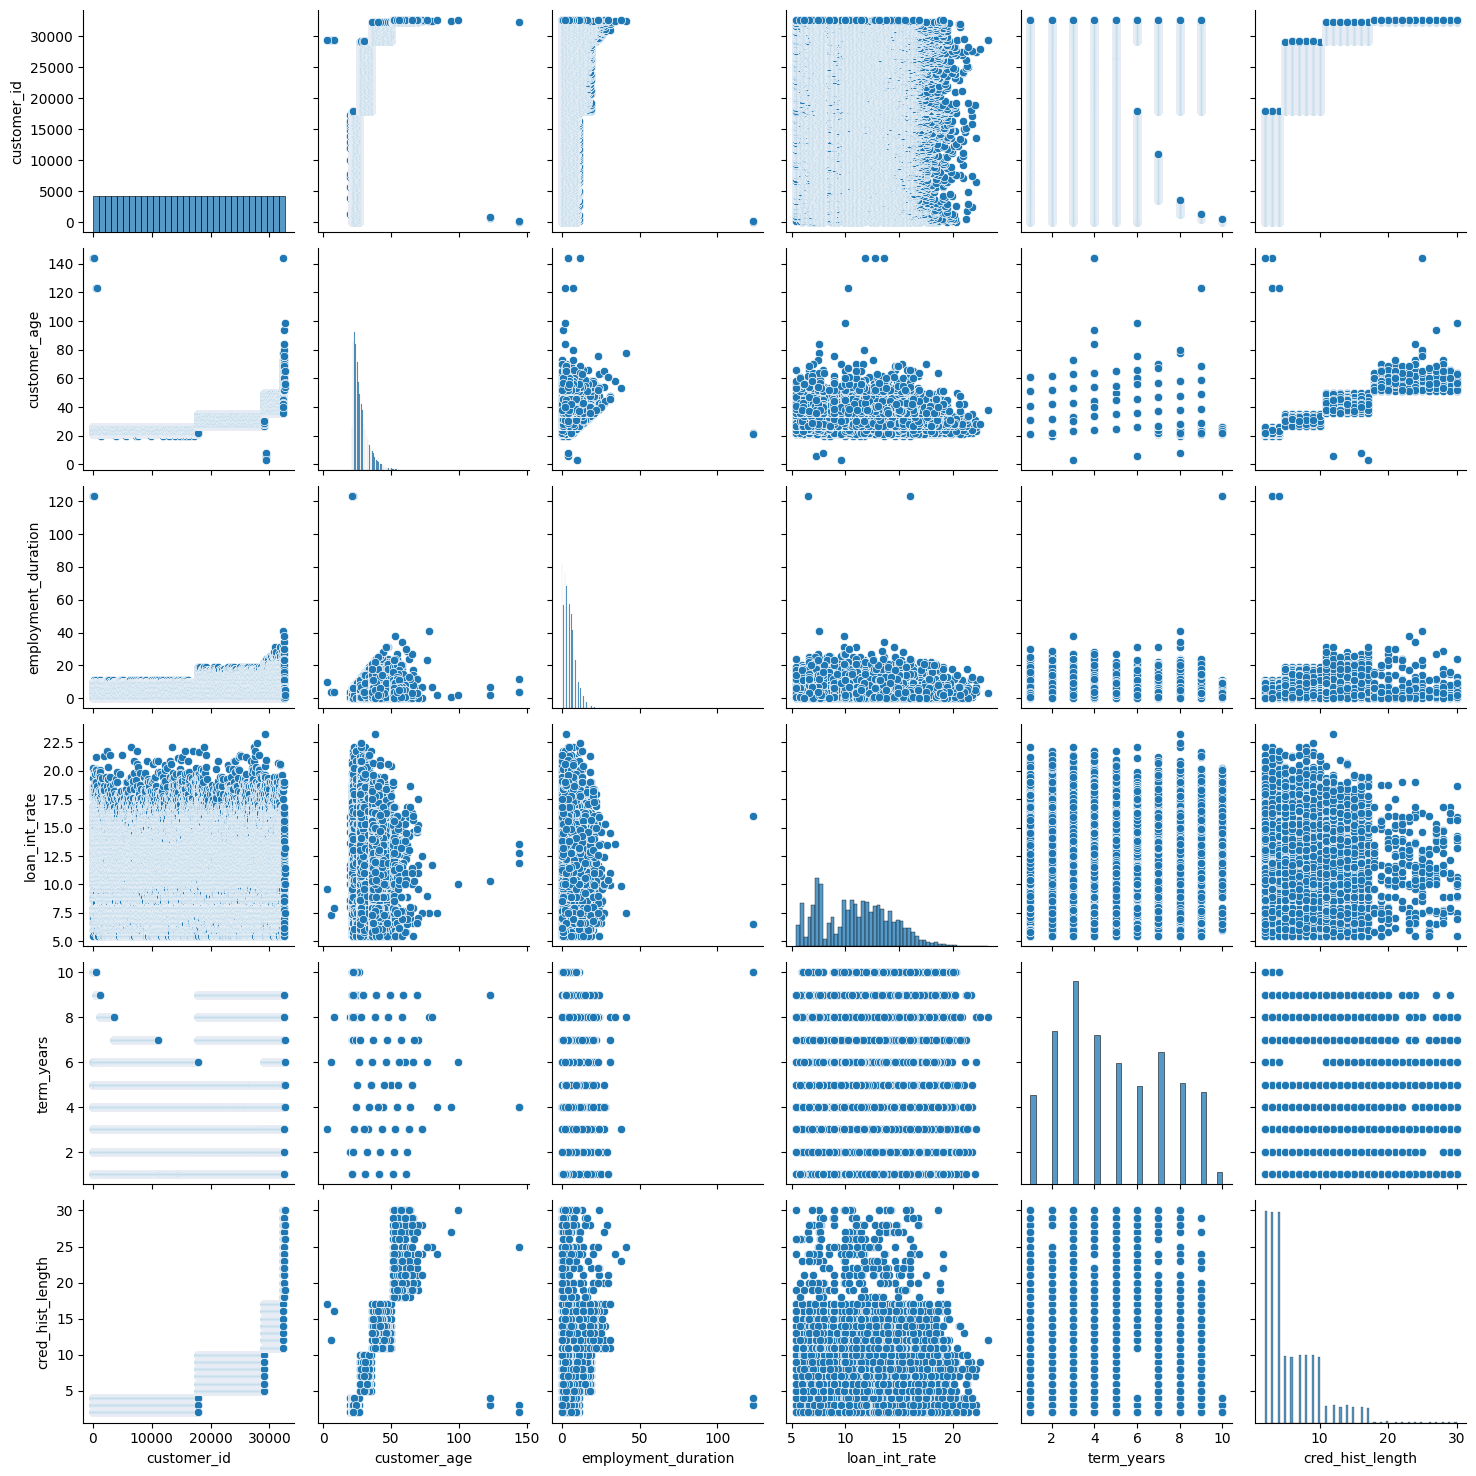

In [77]:
sns.pairplot(data)

In [34]:
cat_col= data.select_dtypes(include= "object")
cat_col.columns

Index(['customer_income', 'home_ownership', 'loan_intent', 'loan_grade',
       'loan_amnt', 'Current_loan_status'],
      dtype='object')

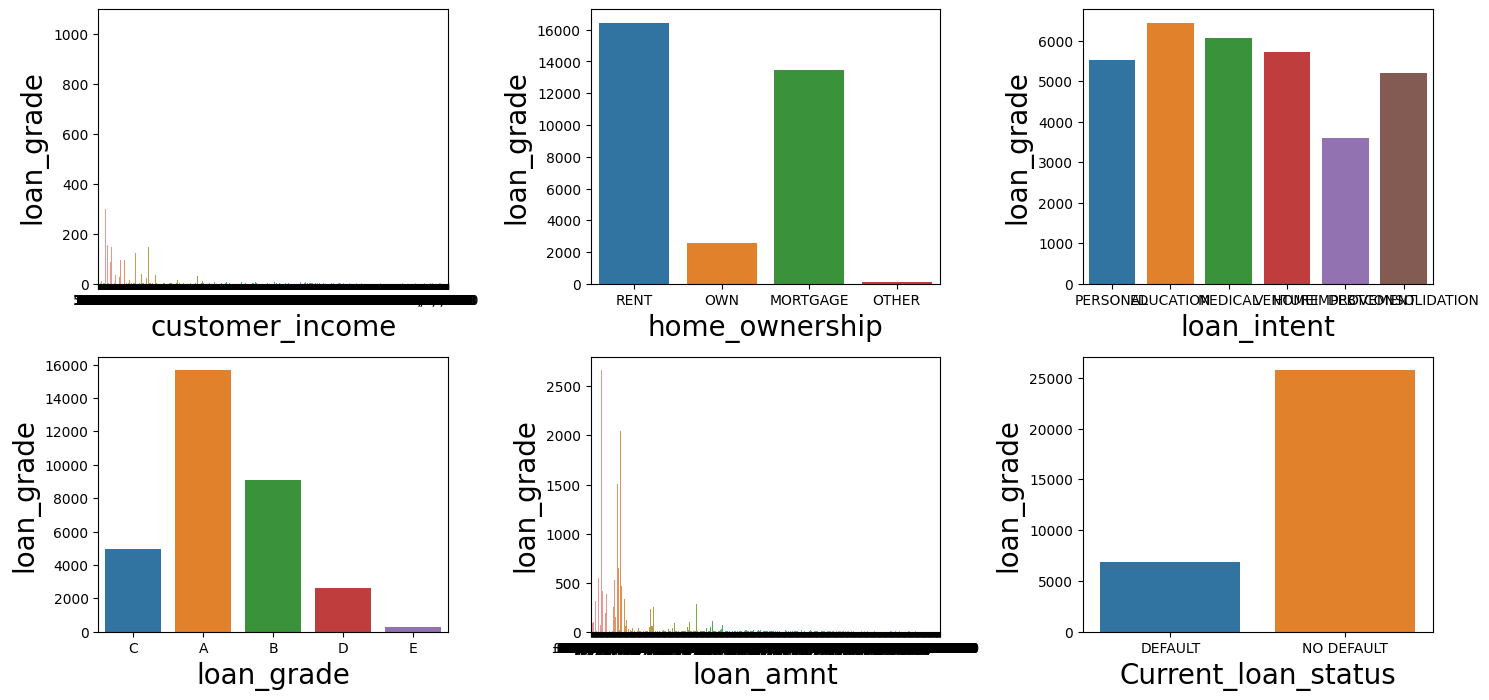

In [79]:
plt.figure(figsize=(15,10))
i= 1

for column in cat_col:
    if i<9:
        ax= plt.subplot(3,3,i)
        sns.countplot(x=data[column])
        plt.xlabel(column,fontsize= 20)
        plt.ylabel("loan_grade",fontsize = 20)
    i+= 1
plt.tight_layout()

In [35]:
num_col= data.select_dtypes(include= ["int","float"])
num_col.columns

Index(['customer_id', 'customer_age', 'employment_duration', 'loan_int_rate',
       'term_years', 'cred_hist_length'],
      dtype='object')

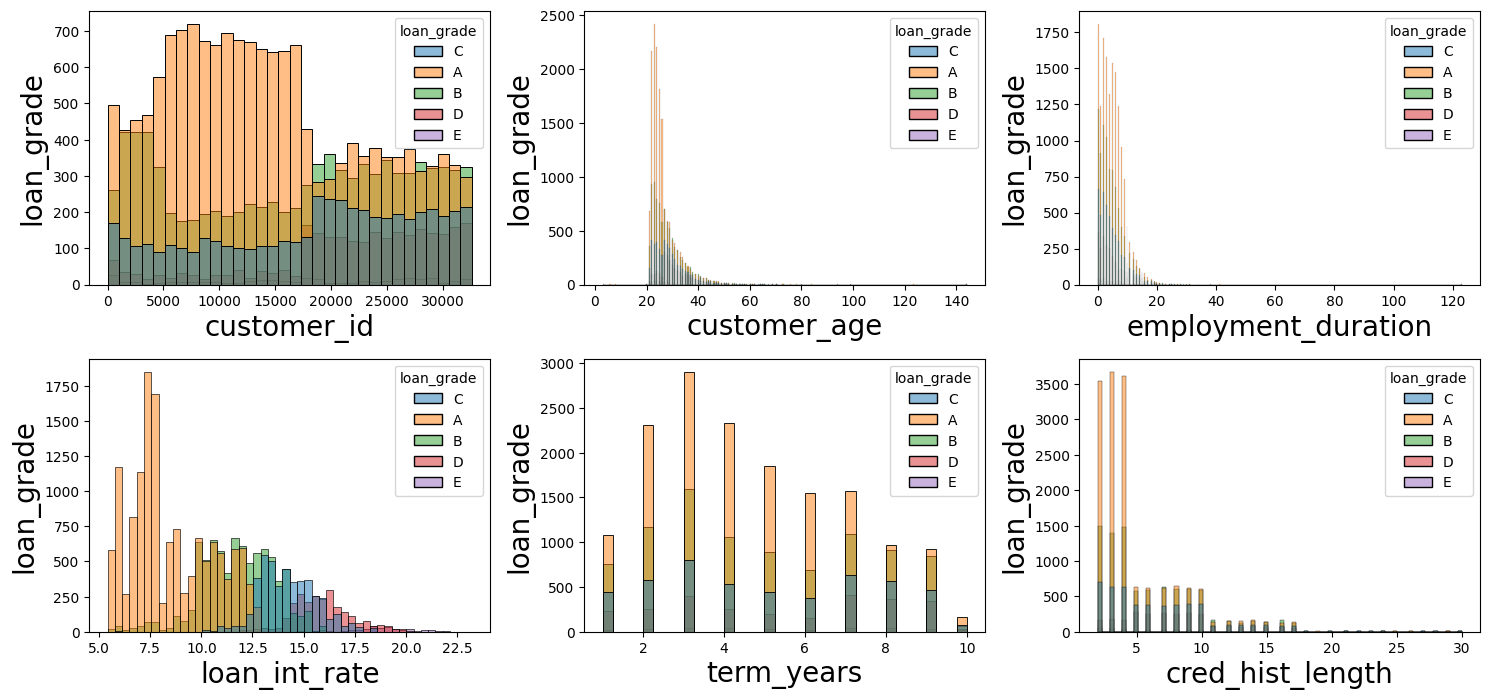

In [83]:
plt.figure(figsize=(15,10))
i= 1

for column in num_col:
    if i<9:
        ax= plt.subplot(3,3,i)
        sns.histplot(x=data[column],hue=data["loan_grade"])
        plt.xlabel(column,fontsize= 20)
        plt.ylabel("loan_grade",fontsize = 20)
    i+= 1
plt.tight_layout()

Insights
1. Maximum numbers of coustomer are in between 20-30 year.
2. Maximum employee duration is in btween 0-10.
3. Interest rate is high for Grade A.
4. Maximun people take 3 year of lone term and min 10 years.

In [36]:
# changing the dtype of coutomer_income and loan_amount for better understanding
# Convert 'customer_income' column to strings
data['customer_income'] = data['customer_income'].astype(str)

# Convert non-numeric values in the 'customer_income' column to numeric values
data['customer_income'] = data['customer_income'].apply(lambda x: int(x.replace(',', '')))

In [37]:
data["loan_amnt"].dropna()

0        £35,000.00
1         £1,000.00
2         £5,500.00
3        £35,000.00
4        £35,000.00
            ...    
32581     £5,800.00
32582    £17,625.00
32583    £35,000.00
32584    £15,000.00
32585     £6,475.00
Name: loan_amnt, Length: 32585, dtype: object

In [38]:
data['loan_amnt'] = data['loan_amnt'].astype(str)
li=[]
for i in range(32586):
    s=""
    for i in data["loan_amnt"][i]:
        if i!=',' and i!='£':
            s=s+i
    li.append(float(s))

In [39]:
data["loan_amnt"]=li

In [40]:
data.dtypes

customer_id            float64
customer_age             int64
customer_income          int64
home_ownership          object
employment_duration    float64
loan_intent             object
loan_grade              object
loan_amnt              float64
loan_int_rate          float64
term_years               int64
cred_hist_length         int64
Current_loan_status     object
dtype: object

<Axes: xlabel='home_ownership', ylabel='customer_income'>

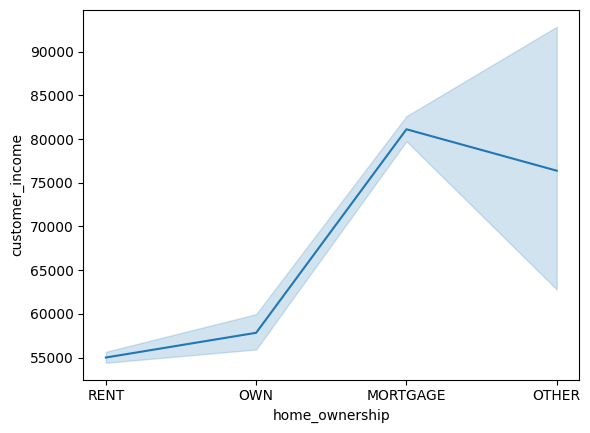

In [18]:
sns.lineplot(data=data, x='home_ownership', y='customer_income')

Insight
:- As the income of the customer is increasing the home ownership is also increasing

([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'PERSONAL'),
  Text(1, 0, 'EDUCATION'),
  Text(2, 0, 'MEDICAL'),
  Text(3, 0, 'VENTURE'),
  Text(4, 0, 'HOMEIMPROVEMENT'),
  Text(5, 0, 'DEBTCONSOLIDATION')])

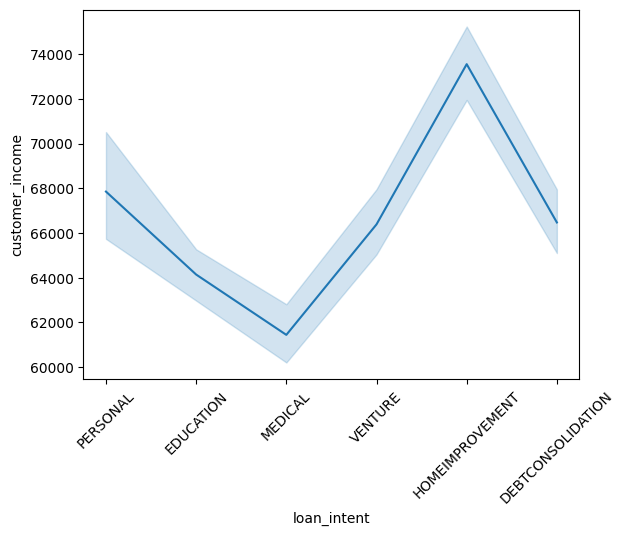

In [99]:
sns.lineplot(data=data, x='loan_intent', y='customer_income')
plt.xticks(rotation=45)

Insights

:- Maximum loan is taken for home improvement

:- Minimun loan is take for Medical

<Axes: xlabel='loan_grade', ylabel='customer_income'>

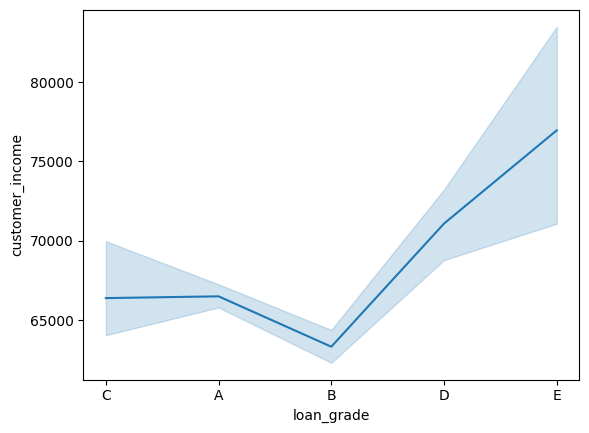

In [53]:
sns.lineplot(data=data, x='loan_grade', y='customer_income')

<Axes: xlabel='term_years', ylabel='customer_income'>

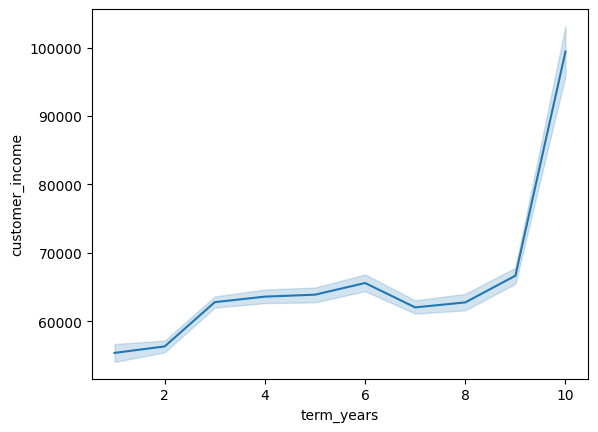

In [138]:
sns.lineplot(data=data, x='term_years', y='customer_income')

<Axes: xlabel='customer_income', ylabel='loan_amnt'>

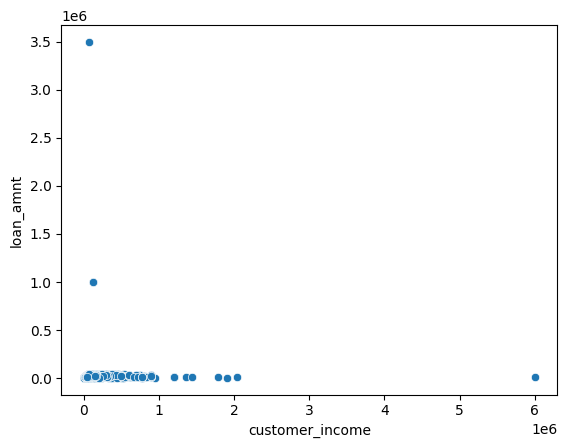

In [104]:
sns.scatterplot(data=data, x='customer_income', y='loan_amnt')

<Axes: xlabel='home_ownership', ylabel='loan_amnt'>

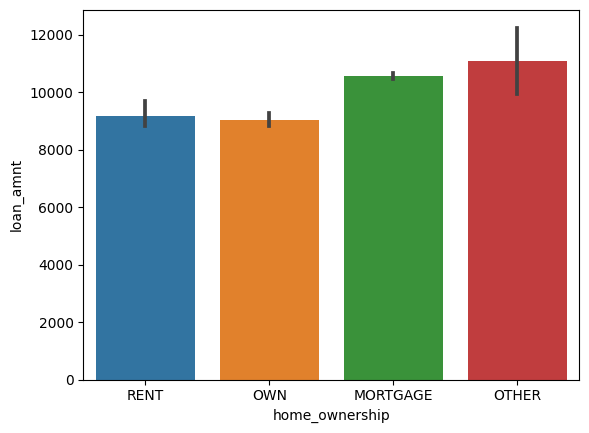

In [101]:
sns.barplot(data=data, x='home_ownership', y='loan_amnt')

(array([0, 1, 2, 3, 4, 5]),
 [Text(0, 0, '0'),
  Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5')])

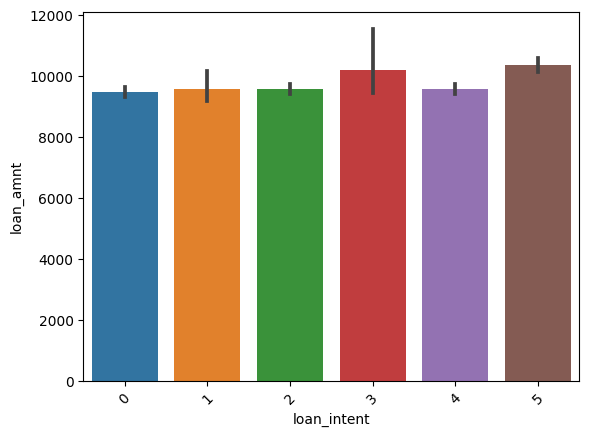

In [139]:
sns.barplot(data=data, x='loan_intent', y='loan_amnt')
plt.xticks(rotation=45)

<Axes: xlabel='loan_grade', ylabel='loan_amnt'>

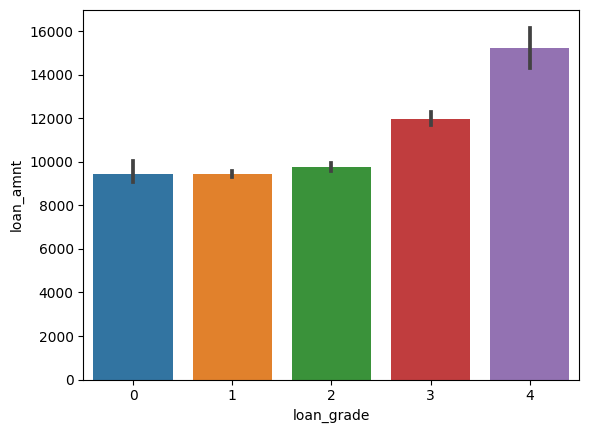

In [140]:
sns.barplot(data=data, x='loan_grade', y='loan_amnt')

<Axes: xlabel='term_years', ylabel='loan_amnt'>

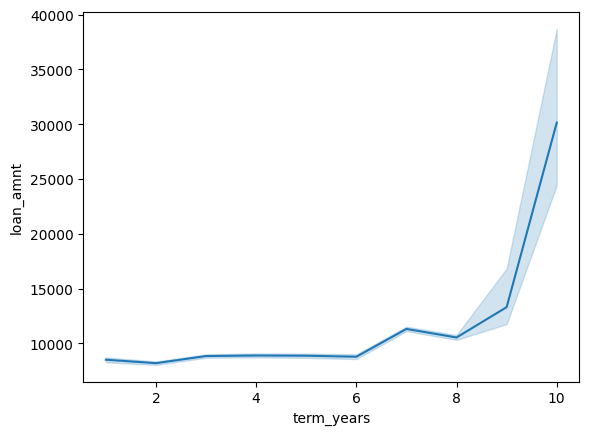

In [141]:
sns.lineplot(data=data, x='term_years', y='loan_amnt')

# Data Preprocessing and Cleaning

In [41]:
# Handling null values
data.loc[data['employment_duration'].isnull()==True,'employment_duration'] =data['employment_duration'].mean()
data.loc[data['loan_int_rate'].isnull()==True,'loan_int_rate'] =data['loan_int_rate'].mean()

In [42]:
data.dropna(inplace=True)
data=data.reset_index()

In [43]:
# Encoding
print(data["home_ownership"].value_counts())
data['home_ownership'] = data['home_ownership'].map({"RENT":0,"OWN":1,"MORTGAGE":2,"OTHER":3})

home_ownership
RENT        16447
MORTGAGE    13441
OWN          2583
OTHER         107
Name: count, dtype: int64


In [44]:
print(data["loan_intent"].value_counts())
data["loan_intent"] = data["loan_intent"].map({"EDUCATION":0,"MEDICAL":1,"VENTURE":2,"PERSONAL":3,"DEBTCONSOLIDATION":4,"HOMEIMPROVEMENT":5})

loan_intent
EDUCATION            6453
MEDICAL              6072
VENTURE              5717
PERSONAL             5519
DEBTCONSOLIDATION    5211
HOMEIMPROVEMENT      3606
Name: count, dtype: int64


In [45]:
print(data["loan_grade"].value_counts())
data["loan_grade"] = data["loan_grade"].map({"A":0,"B":1,"C":2,"D":3,"E":4})

loan_grade
A    15660
B     9060
C     4925
D     2628
E      305
Name: count, dtype: int64


In [46]:
print(data["Current_loan_status"].value_counts())
data["Current_loan_status"] = data["Current_loan_status"].map({"NO DEFAULT":0,"DEFAULT":1})

Current_loan_status
NO DEFAULT    25740
DEFAULT        6838
Name: count, dtype: int64


<Axes: >

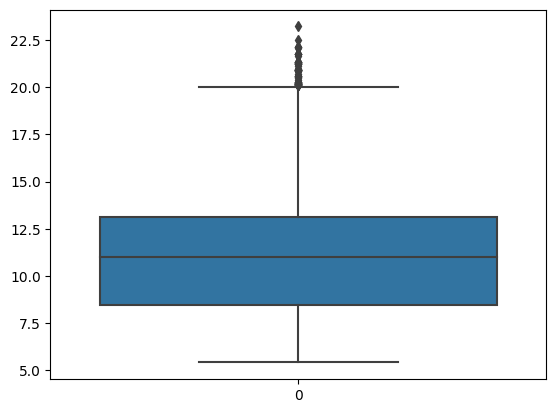

In [26]:
# Handling Outlier
sns.boxplot(data["loan_int_rate"])

In [47]:
q1=data["loan_int_rate"].quantile(0.25)
q3=data["loan_int_rate"].quantile(0.75)
iqr=q3-q1
upper_limit=q3+1.5*iqr
lower_limit=q1-1.5*iqr

data["loan_int_rate"]=np.where(data["loan_int_rate"]>upper_limit,upper_limit,np.where(data["loan_int_rate"]<lower_limit,lower_limit,data["loan_int_rate"]))

<Axes: >

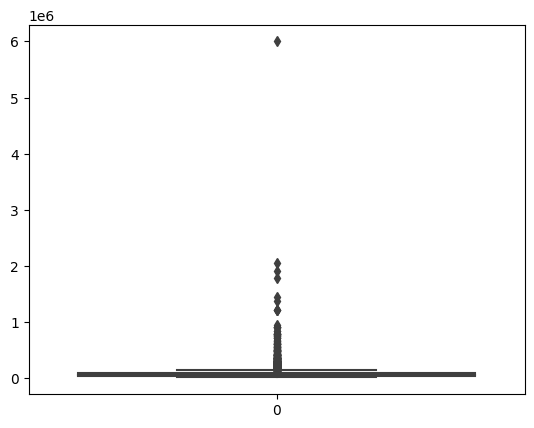

In [117]:
sns.boxplot(data["customer_income"])

In [48]:
q1=data["customer_income"].quantile(0.25)
q3=data["customer_income"].quantile(0.75)
iqr=q3-q1
upper_limit=q3+1.5*iqr
lower_limit=q1-1.5*iqr

data["customer_income"]=np.where(data["customer_income"]>upper_limit,upper_limit,np.where(data["customer_income"]<lower_limit,lower_limit,data["customer_income"]))

<Axes: >

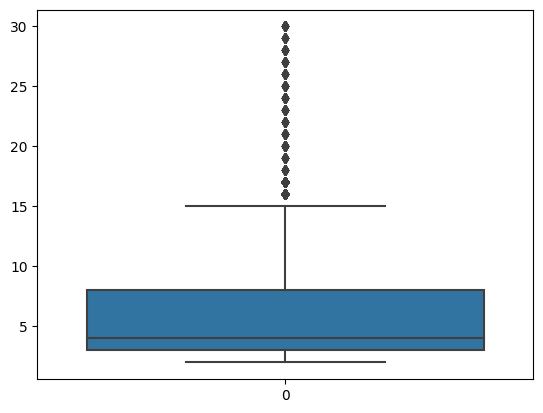

In [119]:
sns.boxplot(data["cred_hist_length"])

In [49]:
q1=data["cred_hist_length"].quantile(0.25)
q3=data["cred_hist_length"].quantile(0.75)
iqr=q3-q1
upper_limit=q3+1.5*iqr
lower_limit=q1-1.5*iqr

data["cred_hist_length"] = np.where(data["cred_hist_length"]>upper_limit,upper_limit,np.where(data["cred_hist_length"]<lower_limit,lower_limit,data["cred_hist_length"]))

<Axes: >

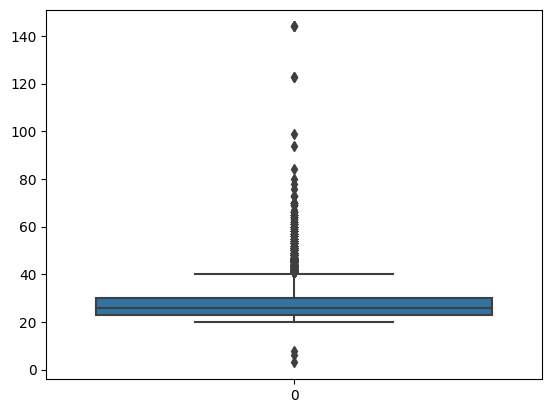

In [121]:
sns.boxplot(data["customer_age"])

In [50]:
q1=data["customer_age"].quantile(0.25)
q3=data["customer_age"].quantile(0.75)
iqr=q3-q1
upper_limit=q3+1.5*iqr
lower_limit=q1-1.5*iqr

data["customer_age"] = np.where(data["customer_age"]>upper_limit,upper_limit,np.where(data["customer_age"]<lower_limit,lower_limit,data["customer_age"]))

<Axes: >

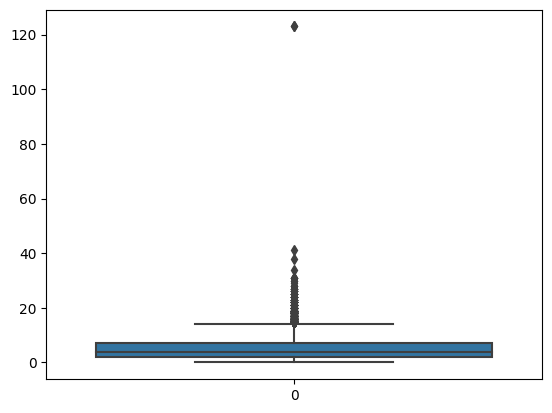

In [124]:
sns.boxplot(data["employment_duration"])

In [51]:
q1=data["employment_duration"].quantile(0.25)
q3=data["employment_duration"].quantile(0.75)
iqr=q3-q1
upper_limit=q3+1.5*iqr
lower_limit=q1-1.5*iqr

data["employment_duration"] = np.where(data["employment_duration"]>upper_limit,upper_limit,np.where(data["employment_duration"]<lower_limit,lower_limit,data["employment_duration"]))

In [52]:
# Scaling The dataset
import sklearn
from sklearn.preprocessing import MinMaxScaler

data[["loan_int_rate","customer_income","cred_hist_length","customer_age","employment_duration","loan_amnt"]] = MinMaxScaler().fit_transform(data[["loan_int_rate","customer_income","cred_hist_length","customer_age","employment_duration","loan_amnt"]])

# Feature Selection

In [53]:
# Droping Unique Value
data = data.drop(['customer_id',"index"], axis=1)

<Axes: >

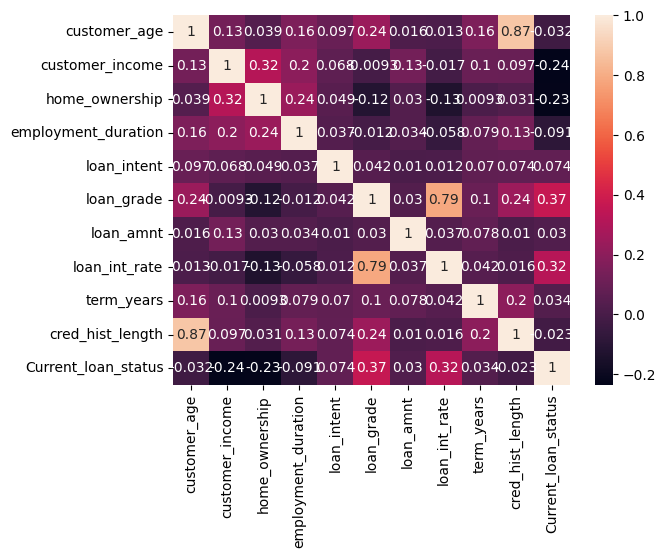

In [34]:
# HeatMap
sns.heatmap(data.corr(),annot=True)

In [54]:
# The relation between cred_hist_lenght and customer_age is 0.87, we can drop any one column
data= data.drop(["cred_hist_length"],axis=1)

In [36]:
data.head()

,customer_age,customer_income,home_ownership,employment_duration,loan_intent,loan_grade,loan_amnt,loan_int_rate,term_years,Current_loan_status
0,0.339286,0.403670,0,1.000000,3,2,0.009859,0.725034,10,1
1,0.303571,0.041101,1,0.344828,0,0,0.000143,0.391245,1,0
2,0.446429,0.041101,2,0.068966,1,1,0.001429,0.509576,5,1
3,0.375000,0.451376,0,0.275862,1,1,0.009859,0.670999,10,1
4,0.410714,0.369908,0,0.551724,1,1,0.009859,0.605335,10,1


# Model Building

In [55]:
# split the data into x and y
x = data.drop('loan_grade',axis=1)
y = data['loan_grade']

In [56]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.30, random_state=42)

In [57]:
data['loan_grade'].value_counts()

loan_grade
0    15660
1     9060
2     4925
3     2628
4      305
Name: count, dtype: int64

In [58]:
!pip install -U imbalanced-learn

In [59]:
from imblearn.over_sampling import SMOTE
smote = SMOTE()

In [60]:
x_smote , y_smote = smote.fit_resample(x_train,y_train)

In [61]:
from collections import Counter
print(Counter(y_train))
print(Counter(y_smote))

Counter({0: 10900, 1: 6343, 2: 3462, 3: 1886, 4: 213})
Counter({0: 10900, 1: 10900, 2: 10900, 3: 10900, 4: 10900})


In [62]:
# Algorithm
from sklearn.svm import SVC

model = SVC()

model.fit(x_smote, y_smote)

SVC()

In [63]:
y_pred = model.predict(x_test)

In [64]:
from sklearn.metrics import accuracy_score
print("accuracy_score: ",accuracy_score(y_test,y_pred))


accuracy_score:  0.7387968078575813


# Cross Validation

In [65]:
from sklearn.model_selection import cross_val_score

cross_val = cross_val_score(model,x,y,cv=10,scoring = 'accuracy')

In [66]:
cross_val

array([0.60036832, 0.68600368, 0.7704113 , 0.74554942, 0.72191529,
       0.73664825, 0.74309392, 0.74248005, 0.79121891, 0.62235186])

In [67]:
print('Cross validation score',cross_val.std())
#if std() is less than 0.05 then we say the model is working good

Cross validation score 0.058675969847158546


In [53]:
# Hyperparameter tuning

# Decision Tree

In [68]:
#import the algoo
from sklearn.tree import DecisionTreeClassifier

#init
model = DecisionTreeClassifier()

#train
model.fit(x_smote,y_smote)

DecisionTreeClassifier()

In [69]:
y_test_pred = model.predict(x_test)
accuracy_score(y_test,y_test_pred)

0.8443830570902394

In [70]:
y_train_pred= model.predict(x_smote)
accuracy_score(y_smote,y_train_pred)

0.9998532110091743

In [71]:
from sklearn.metrics import confusion_matrix
confusion_matrix = confusion_matrix(y_test, y_test_pred)
print("Confusion Matrix:\n", confusion_matrix)

Confusion Matrix:
 [[4348  314   67   27    4]
 [ 245 2263  155   47    7]
 [  50  139 1050  172   52]
 [  15   20  109  541   57]
 [   4    1    7   29   51]]


# Random Forest

In [72]:
from sklearn.ensemble import RandomForestClassifier

model_rf=RandomForestClassifier() # by default it is building 100 estimators

model_rf.fit(x_smote,y_smote)

RandomForestClassifier()

In [73]:
y_pred_rf = model_rf.predict(x_test)

In [74]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred_rf)

0.8717004297114794